In [1]:
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_PATH = "C:/Users/kalam/F1 Project Outcome Prediction/data/processed/"
f1 = pd.read_csv(PROCESSED_PATH + "f1_merged.csv")

In [2]:
f1["positionOrder"] = pd.to_numeric(f1["positionOrder"], errors="coerce")
f1["grid"] = pd.to_numeric(f1["grid"], errors="coerce")

In [3]:
finished_keywords = ["Finished", "+1 Lap", "+2 Laps", "+3 Laps", "+4 Laps", "+5 Laps", "+6 Laps", "+7 Laps"]
f1["is_dnf"] = (~f1["race_status"].isin(finished_keywords)).astype(int)

dnf_rate = f1["is_dnf"].mean()
print("Overall DNF rate:", round(dnf_rate * 100, 2), "%")

Overall DNF rate: 44.19 %


In [4]:
pole = f1[f1["grid"] == 1]
pole_wins = pole[pole["positionOrder"] == 1]

pole_win_pct = len(pole_wins) / len(pole) * 100
print("Pole-to-win percentage:", round(pole_win_pct, 2), "%")

Pole-to-win percentage: 42.34 %


In [5]:
f1["positions_gained"] = f1["grid"] - f1["positionOrder"]
gainers = f1.groupby("driver_name", as_index=False)["positions_gained"].mean()
gainers = gainers.sort_values("positions_gained", ascending=False).head(10)
gainers

,driver_name,positions_gained
287,George Amick,23.0
117,Bud Tingelstad,19.0
120,Carl Forberg,17.0
242,Ernst Klodwig,17.0
594,Mike Sparken,16.0
512,Larry Crockett,16.0
200,Dieter Quester,16.0
329,Guy Tunmer,14.0
80,Bill Mackey,14.0
263,Frank Armi,14.0


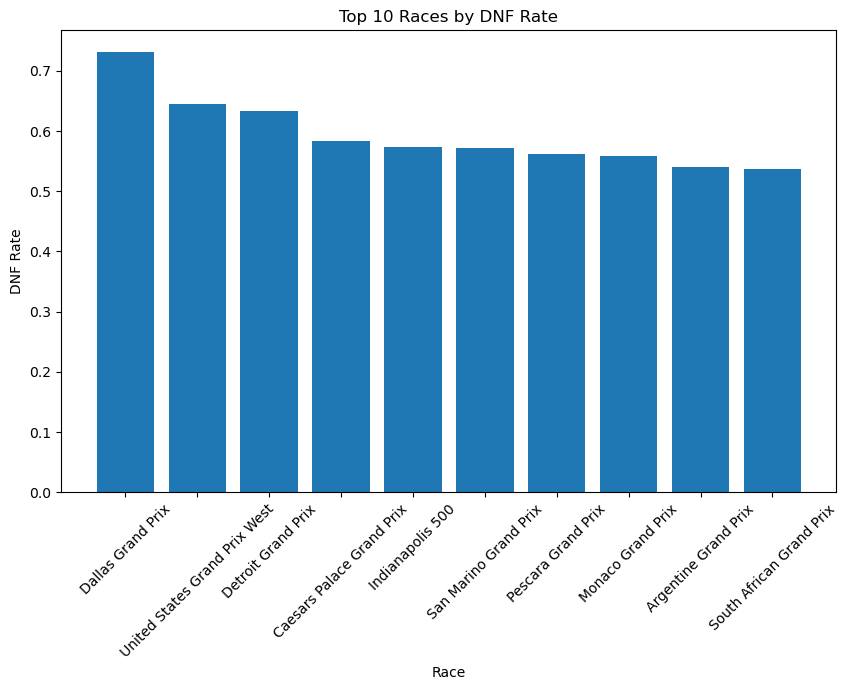

In [6]:
circuit_dnf = f1.groupby("race_name", as_index=False)["is_dnf"].mean()
circuit_dnf = circuit_dnf.sort_values("is_dnf", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(circuit_dnf["race_name"], circuit_dnf["is_dnf"])
plt.title("Top 10 Races by DNF Rate")
plt.xlabel("Race")
plt.ylabel("DNF Rate")
plt.xticks(rotation=45)
plt.show()

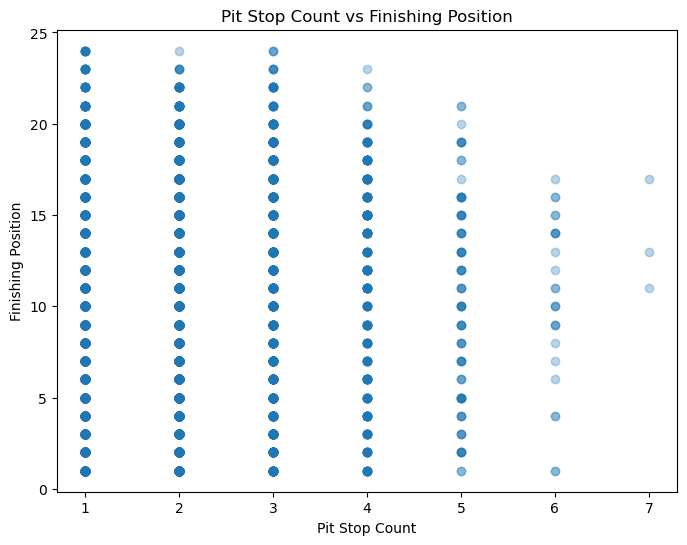

In [7]:
pit_df = f1[["pit_stop_count", "positionOrder"]].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(pit_df["pit_stop_count"], pit_df["positionOrder"], alpha=0.3)
plt.title("Pit Stop Count vs Finishing Position")
plt.xlabel("Pit Stop Count")
plt.ylabel("Finishing Position")
plt.show()